In [2]:
import pandas as pd

# === YouTube ===
yt = pd.read_csv("youtube_brainrot/comments_final.csv")
yt_unified = pd.DataFrame({
    "text": yt["text"],
    "platform": "youtube",
    "source_id": yt["video_id"],
    "author": yt["author"],
    "likes": yt["likes"],
    "timestamp": yt["published"],
    "is_reply": yt["is_reply"],
    "lang": None,  # определим позже
})

# === Pikabu комменты ===
pk_c = pd.read_csv("pikabu_brainrot/comments.csv")
pk_c_unified = pd.DataFrame({
    "text": pk_c["text"],
    "platform": "pikabu_comment",
    "source_id": pk_c["story_id"].astype(str),
    "author": pk_c["author"],
    "likes": pk_c["rating"],
    "timestamp": None,
    "is_reply": pk_c["parent_id"].notna(),
    "lang": "ru",  # Pikabu = русский
})

# === Pikabu заголовки + тела ===
pk_p = pd.read_csv("pikabu_brainrot/posts_with_body.csv")
pk_titles = pd.DataFrame({
    "text": pk_p["title"],
    "platform": "pikabu_title",
    "source_id": pk_p["post_id"].astype(str),
    "author": pk_p["author"],
    "likes": pk_p["rating"],
    "timestamp": pk_p["published"],
    "is_reply": False,
    "lang": "ru",
})

# Тела постов (только непустые)
pk_bodies = pk_p[pk_p["body"].notna() & (pk_p["body"].str.len() > 20)].copy()
pk_bodies_unified = pd.DataFrame({
    "text": pk_bodies["body"],
    "platform": "pikabu_body",
    "source_id": pk_bodies["post_id"].astype(str),
    "author": pk_bodies["author"],
    "likes": pk_bodies["rating"],
    "timestamp": pk_bodies["published"],
    "is_reply": False,
    "lang": "ru",
})

# === Объединяем ===
corpus = pd.concat(
    [yt_unified, pk_c_unified, pk_titles, pk_bodies_unified],
    ignore_index=True
)

# Чистим
corpus = corpus[corpus["text"].notna()]
corpus = corpus[corpus["text"].astype(str).str.len() >= 3]  # минимум 3 символа
corpus = corpus.drop_duplicates(subset=["text"]).reset_index(drop=True)

# Сохраняем единый корпус
corpus.to_parquet("brainrot_corpus.parquet", index=False)
corpus.to_csv("brainrot_corpus.csv", index=False)

print(f"📊 Итоговый корпус:")
print(corpus["platform"].value_counts())
print(f"Всего записей: {len(corpus)}")
print(f"Уникальных авторов: {corpus['author'].nunique()}")

📊 Итоговый корпус:
platform
youtube           202077
pikabu_comment      6576
pikabu_title         366
pikabu_body          209
Name: count, dtype: int64
Всего записей: 209228
Уникальных авторов: 181401


In [4]:
corpus

,text,platform,source_id,author,likes,timestamp,is_reply,lang
0,"Я настолько стар, что помню времена, когда мем...",youtube,e2Vzk4AZpMA,@Bazar_net968,1610.0,2025-04-27T12:12:59Z,False,None
1,Тебя повезло что ты дожил до времени с нормаль...,youtube,e2Vzk4AZpMA,@Tam2112,42.0,2025-04-27T13:22:40Z,True,None
2,Правед мадвед😊,youtube,e2Vzk4AZpMA,@IS-3_love,16.0,2025-04-27T13:59:14Z,True,None
3,ну и лох.,youtube,e2Vzk4AZpMA,@karandash1861,0.0,2025-04-27T14:55:44Z,True,None
4,"Честно, ни один сгенерированный ИИ мем ни разу...",youtube,e2Vzk4AZpMA,@-Ozer-,57.0,2025-04-27T16:01:07Z,True,None
...,...,...,...,...,...,...,...,...
209223,"Ирландец провожает мигрантов, уезжающих из-за ...",pikabu_body,14057777,skvoretso,4177.0,2026-06-13T05:04:58+03:00,False,ru
209224,Наткнулся на такой пост в ТГ (автор бывший адв...,pikabu_body,14058826,Nikural,754.0,2026-06-13T13:44:02+03:00,False,ru
209225,Перейти к видео После нападения волкособа на м...,pikabu_body,4,NaN,1296.0,2026-06-13T09:00:00+03:00,False,ru
209226,"Как потребитель скажу, надпись на упаковке ""сд...",pikabu_body,700,user6225055,1703.0,2026-06-13T12:23:18+03:00,False,ru


In [5]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 3.4 MB/s  0:00:0036m-:--:--
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993332 sha256=b700d3319d888e2d603197cf01a35c6b7d80f71db33943bdf34bcc647c39f798
  Stored in directory: /Users/user/Library/Caches/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [90]:
# ============================================================
# СЛОВАРИ МАРКЕРОВ ДЛЯ ФИЛЬТРАЦИИ КОРПУСА
# ============================================================

# ─────────────────────────────────────────────────────────────
# 1. BRAINROT / МЕМЫ НА ЛАТИНИЦЕ
#    (типичные англ. термины, которые встречаются и в ру-текстах)
# ─────────────────────────────────────────────────────────────
BRAINROT_LATIN_MARKERS = {
    # === Числовые мемы ===
    "six seven", "six-seven", "67", "6 7", "6-7",
    "41", "93", "322", "7x7", "7 7", "49",
    
    # === Skibidi-вселенная ===
    "skibidi", "skibidi toilet", "skibidi sigma", "skibidi ohio",
    
    # === Italian brainrot (огромный пласт 2025) ===
    "tralalero", "tralala", "tralalelo",
    "bombardiro", "bombardino", "crocodilo",
    "ballerina cappuccina", "cappuccina",
    "tung tung tung", "tung tung sahur", "sahur",
    "bombombini", "gusini", "lirili larila",
    "brr brr patapim", "patapim",
    "chimpanzini bananini", "bananini",
    "trippi troppi", "boneca ambalabu",
    "frigo camelo", "burbaloni luliloli",
    
    # === Альфа/сигма/бета-маскулинность ===
    "rizz", "rizzler", "rizzed", "w rizz", "l rizz", "unspoken rizz",
    "sigma", "sigma male", "sigma boy", "sigma grindset",
    "alpha", "alpha male", "beta", "beta male", "omega",
    "gigachad", "chad", "mewing", "mew",
    "looksmax", "looksmaxx", "looksmaxxing", "mogged", "mogging", "mog",
    "gyatt", "gyat",
    
    # === Эмоции/реакции ===
    "ohio", "only in ohio", "fanum tax", "fanum",
    "delulu", "no cap", "cap", "no chill", "bet",
    "sus", "amogus", "among us", "imposter",
    "slay", "slayed", "ate", "ate that", "ate down",
    "based", "cringe", "cringy",
    "npc", "npc behavior",
    "goon", "gooning", "edge", "edging",
    "huzz", "bruzz", "yappin", "yapping",
    "glaze", "glazing", "glazed",
    "aura", "aura points", "negative aura",
    "diddy", "diddyblud", "blud", "bruv",
    "nonchalant", "demure",
    
    # === Гендерные/возрастные мемы ===
    "pick me", "pickme", "pikmi",
    "boy math", "girl math", "boy dinner", "girl dinner",
    "unc", "unc behavior", "auntie", "old head",
    
    # === Реакции и фразы ===
    "lowkey", "highkey", "lowkenuinely",
    "vibe", "vibes", "vibing", "vibe check",
    "mood", "mid", "peak", "peak fiction",
    "fire", "lit", "bussin", "bussin bussin",
    "deadass", "fr", "fr fr", "ngl", "tbh", "imo",
    "pov", "iykyk", "ts pmo",
    "real", "so real", "this is so real",
    "it's giving", "its giving",
    "say less", "spill the tea", "tea",
    "drip", "dripping", "drippy",
    "main character", "side character",
    
    # === Игровой/интернет-сленг ===
    "gg", "ez", "noob", "tryhard", "smurf",
    "ratio", "l ratio", "w ratio", "take the l",
    "touch grass", "go outside", "terminally online",
    "brainrot", "brain rot", "doomscroll", "doomscrolling",
    
    # === Slang words из 2025-26 ===
    "sybau", "tuff", "tuah", "hawk tuah",
    "67 kid", "rizzler", "skibidi rizz",
    "put the fries in the bag",
    "chopped", "cooked", "ate", "ate up",
    
    # === Музыкальные/танцевальные тренды ===
    "doot doot", "skrilla",
}

# ─────────────────────────────────────────────────────────────
# 2. РУ-СЛЕНГ И БРЕЙНРОТ КИРИЛЛИЦЕЙ
#    (тоже маркеры — если совпадают, точно ру-контент)
# ─────────────────────────────────────────────────────────────
BRAINROT_CYRILLIC_MARKERS = {
    # === Числовые мемы (русифицированные) ===
    "сикс севен", "сикс-севен", "сиксевен",
    "шесть семь", "шесть-семь",
    "сорок два", "пятьдесят два",
    "сикс уан",
    
    # === Транслитерации западного brainrot ===
    "скибиди", "скибиди туалет",
    "ризз", "ризлер", "ризз-",
    "сигма", "сигма-бой", "сигма бой", "сигма-гриндсет",
    "альфа", "альфач", "бета", "омега",
    "гигачад", "чад",
    "мьюинг", "мьюить",
    "луксмаксинг", "луксмакс",
    "огайо", "охайо",
    "фанум такс", "фанум-такс",
    "делулу", "ноу кап", "кап",
    "соз", "ам анг ас", "имба", "имбовый",
    "слэй", "слэйнуть",
    "крендж", "кринж", "кринжовый", "кринжово","энписи", "нпс",
    "гун", "гунить", "эдж",
    
    # === Italian brainrot кириллицей ===
    "тралалело", "тралалеро", "тралала",
    "бомбардино", "бомбардиро",
    "балерина капучина", "капучина",
    "тунг тунг", "сахур",
    
    # === Русский brainrot/сленг ===
    "окак", "анк", "лейм", "докс",
    "чиназес", "чизабретто", "черемша",
    "босс kfc", "босс кфс", "босс художки",
    "нормис", "пикми",
    "сидим с бобром",
    "пупуня", "нетакуся",
    "ауф", "ауфно",
    "краш", "крашиха", "крашиться",
    "флекс", "флексить", "флексовый",
    "чилл", "чилить", "чиллово",
    "вайб", "вайбовый", "вайбить",
    "хайп", "хайповый", "хайпить",
    "рофл", "рофлить", "рофлово",
    "скуф", "скуфы", "скуфидон",
    "альт", "альтушка", "альты",
    "тян", "кун",
    "рэд флаг", "ред флаг", "грин флаг",
    "бести", "бестики",
    
    # === Реакции/эмоции ===
    "база", "база отдела", "база орда",
    "имба", "имбовый", "имбануть",
    "топчик", "топчанский",
    "мид", "мидовый",
    "пик", "пиковый",
    "я в прайме", "прайм", "прайм-эра",
    "тильт", "тильтануть", "тильтить",
    "тащер", "тащить",
    "лагать", "лагает",
    "го", "погнали",
    "изи", "изи катка",
    
    # === Гендерные ===
    "альфач", "бетач", "сигмач",
    "хейтер", "хейтить",
    "симпать", "симп",
    
    # === Тикток-специфика ===
    "тт", "тикток", "тиктокер",
    "пов", "плов",  # POV
    "залетел в рек",
    "фит", "фит чек",
    "эдит", "эдитить",
}

# ─────────────────────────────────────────────────────────────
# 3. ТРАНСЛИТ-МАРКЕРЫ
#    (типичные русские слова, написанные латиницей —
#     признак, что текст русский, даже без кириллицы)
# ─────────────────────────────────────────────────────────────
RU_TRANSLIT_MARKERS = {
    # === Базовые маркеры русского ===
    "privet", "spasibo", "pozhaluysta", "poka",
    "kak dela", "chto eto", "che tam", "che kak",
    "norm", "normalno", "normalek",
    "blin", "blya", "ofigenno", "ohuet",
    "tipa", "voobshche", "voobshe", "voobshem",
    "kek", "lol", "ору", "orem",
    
    # === Частицы и связки ===
    "che ", " che", "shto", "chto", "shtoby",
    "kogda", "potomu", "poetomu", "potom",
    "zachem", "pochemu", "kakoy", "kakaya",
    "menya", "tebya", "ego", "ee",
    "moy", "tvoy", "nash", "vash",
    "etot", "eta", "eto", "vot",
    "uzhe", "eshe", "esche",
    "tozhe", "takzhe", "tolko",
    
    # === Типичные слова разговорной речи ===
    "kruto", "kruta", "klassno", "klass",
    "prikol", "prikolno",
    "ugar", "ugarno",
    "zhest", "zhestko",
    "atas", "ahueno",
    "krasava", "krasavchik",
    "molodec", "molodca",
    "davai", "davay",
    "poshli", "idem",
    "smotri", "glyan",
    "slushai", "slushay",
    "skazhi", "skazal",
    "delaesh", "delal",
    
    # === Транслит-brainrot слов ===
    "krash", "krashik",
    "kringe", "krindzh",
    "imba", "imbovii",
    "siks seven", "siks-seven",
    "skibidi", "alfa", "sigma boy",
    "pikmi", "normis",
    "vaib", "vaibovii",
    "chill", "chillit",
    "ofnik", "ofniki",
}

# ─────────────────────────────────────────────────────────────
# 4. ХЕШТЕГИ-МАРКЕРЫ (часто без пробелов)
# ─────────────────────────────────────────────────────────────
HASHTAG_MARKERS = {
    "#сиксевен", "#сиксsевен", "#67", "#sixseven", "#six_seven",
    "#скибиди", "#skibidi", "#brainrot", "#брейнрот",
    "#сигма", "#sigma", "#sigmaboy", "#сигмабой",
    "#ризз", "#rizz", "#gyatt", "#огайо", "#ohio",
    "#альфа", "#alpha", "#чад", "#chad",
    "#тикток", "#tiktok", "#fyp", "#рек",
    "#мем", "#meme", "#мемы", "#memes",
    "#сленг", "#slang",
    "#покалф", "#genalpha", "#zoomers", "#зумеры",
    "#чиназес", "#окак", "#скуф",
    "#italianbrainrot", "#итальянскийбрейнрот",
    "#tralalero", "#bombardiro",
}


# ─────────────────────────────────────────────────────────────
# ОБЪЕДИНЁННЫЕ СПИСКИ ДЛЯ УДОБСТВА
# ─────────────────────────────────────────────────────────────
ALL_LATIN_MARKERS = BRAINROT_LATIN_MARKERS | RU_TRANSLIT_MARKERS
ALL_CYRILLIC_MARKERS = BRAINROT_CYRILLIC_MARKERS
ALL_MARKERS = ALL_LATIN_MARKERS | ALL_CYRILLIC_MARKERS | HASHTAG_MARKERS


print(f"📚 Загружено маркеров:")
print(f"   • Латиница (brainrot): {len(BRAINROT_LATIN_MARKERS)}")
print(f"   • Кириллица (ру-сленг): {len(BRAINROT_CYRILLIC_MARKERS)}")
print(f"   • Транслит русского:    {len(RU_TRANSLIT_MARKERS)}")
print(f"   • Хештеги:              {len(HASHTAG_MARKERS)}")
print(f"   • Всего уникальных:     {len(ALL_MARKERS)}")

📚 Загружено маркеров:
   • Латиница (brainrot): 183
   • Кириллица (ру-сленг): 146
   • Транслит русского:    101
   • Хештеги:              43
   • Всего уникальных:     470


In [26]:
import pandas as pd
import re
from collections import Counter
from langdetect import detect, DetectorFactory, LangDetectException

DetectorFactory.seed = 42

# ============================================================
# СЛОВАРИ МАРКЕРОВ
# ============================================================

# ─── BRAINROT / МЕМЫ НА ЛАТИНИЦЕ ──────────────────────────────
BRAINROT_LATIN_MARKERS = {
    # Числовые мемы
    "six seven", "six-seven", "67", "6 7", "6-7",
    "41", "93", "322", "7x7", "7 7", "49",
    
    # Skibidi
    "skibidi", "skibidi toilet", "skibidi sigma", "skibidi ohio",
    
    # Italian brainrot
    "tralalero", "tralala", "tralalelo",
    "bombardiro", "bombardino", "crocodilo",
    "ballerina cappuccina", "cappuccina",
    "tung tung tung", "tung tung sahur", "sahur",
    "bombombini", "gusini", "lirili larila",
    "brr brr patapim", "patapim",
    "chimpanzini bananini", "bananini",
    "trippi troppi", "boneca ambalabu",
    "frigo camelo", "burbaloni luliloli",
    
    # Альфа/сигма
    "rizz", "rizzler", "rizzed", "w rizz", "l rizz", "unspoken rizz",
    "sigma", "sigma male", "sigma boy", "sigma grindset",
    "alpha", "alpha male", "beta", "beta male", "omega",
    "gigachad", "chad", "mewing", "mew",
    "looksmax", "looksmaxx", "looksmaxxing", "mogged", "mogging", "mog",
    "gyatt", "gyat",
    
    # Реакции
    "ohio", "only in ohio", "fanum tax", "fanum",
    "delulu", "no cap", "cap", "no chill", "bet",
    "sus", "amogus", "among us", "imposter",
    "slay", "slayed", "ate", "ate that", "ate down",
    "based", "cringe", "cringy",
    "npc", "npc behavior",
    "goon", "gooning", "edge", "edging",
    "huzz", "bruzz", "yappin", "yapping",
    "glaze", "glazing", "glazed",
    "aura", "aura points", "negative aura",
    "diddy", "diddyblud", "blud", "bruv",
    "nonchalant", "demure",
    
    # Gen Alpha
    "pick me", "pickme", "pikmi",
    "boy math", "girl math", "boy dinner", "girl dinner",
    "unc", "unc behavior", "auntie", "old head",
    
    # Реакции
    "lowkey", "highkey",
    "vibe", "vibes", "vibing", "vibe check",
    "mood", "mid", "peak", "peak fiction",
    "fire", "lit", "bussin", "bussin bussin",
    "deadass", "fr", "fr fr", "ngl", "tbh", "imo",
    "pov", "iykyk", "ts pmo",
    "real", "so real", "this is so real",
    "it's giving", "its giving",
    "say less", "spill the tea",
    "drip", "dripping", "drippy",
    "main character", "side character",
    
    # Игровой
    "gg", "ez", "noob", "tryhard", "smurf",
    "ratio", "l ratio", "w ratio", "take the l",
    "touch grass", "go outside", "terminally online",
    "brainrot", "brain rot", "doomscroll", "doomscrolling",
    
    # 2025
    "sybau", "tuff", "tuah", "hawk tuah",
    "67 kid", "skibidi rizz",
    "put the fries in the bag",
    "chopped", "cooked", "ate up",
    "doot doot", "skrilla",
}

# ─── BRAINROT КИРИЛЛИЦЕЙ ──────────────────────────────────────
BRAINROT_CYRILLIC_MARKERS = {
    # Числовые мемы
    "сикс севен", "сикс-севен", "сиксевен",
    "шесть семь", "шесть-семь",
    "сорок два", "пятьдесят два",
    "сикс уан",
    
    # Транслит западного brainrot
    "скибиди", "скибиди туалет",
    "ризз", "ризлер",
    "сигма", "сигма-бой", "сигма бой", "сигма-гриндсет",
    "альфа", "альфач", "бета", "омега",
    "гигачад", "чад",
    "мьюинг", "мьюить",
    "луксмаксинг", "луксмакс",
    "огайо", "охайо",
    "фанум такс", "фанум-такс",
    "делулу", "ноу кап",
    "имба", "имбовый", "имбануть",
    "слэй", "слэйнуть",
    "крендж", "кринж", "кринжовый", "кринжово",
    "энписи", "нпс",
    "гун", "гунить", "эдж",
    
    # Italian brainrot
    "тралалело", "тралалеро", "тралала",
    "бомбардино", "бомбардиро",
    "балерина капучина", "капучина",
    "тунг тунг", "сахур",
    
    # Русский brainrot
    "окак", "анк", "лейм", "докс",
    "чиназес", "чизабретто", "черемша",
    "босс kfc", "босс кфс", "босс художки",
    "нормис", "пикми",
    "сидим с бобром",
    "пупуня", "нетакуся",
    "ауф", "ауфно",
    "краш", "крашиха", "крашиться",
    "флекс", "флексить", "флексовый",
    "чилл", "чилить", "чиллово",
    "вайб", "вайбовый", "вайбить",
    "хайп", "хайповый", "хайпить",
    "рофл", "рофлить", "рофлово",
    "скуф", "скуфы", "скуфидон",
    "альт", "альтушка", "альты",
    "тян", "кун",
    "рэд флаг", "ред флаг", "грин флаг",
    "бести", "бестики",
    
    # Реакции
    "база", "база отдела", "база орда",
    "топчик", "топчанский",
    "мид", "мидовый",
    "пик", "пиковый",
    "я в прайме", "прайм", "прайм-эра",
    "тильт", "тильтануть", "тильтить",
    "тащер", "тащить",
    "лагать", "лагает",
    "го", "погнали",
    "изи", "изи катка",
    
    # Гендерные
    "сигмач",
    "хейтер", "хейтить",
    "симпать", "симп",
    
    # Тикток
    "тт", "тикток", "тиктокер",
    "пов",
    "залетел в рек",
    "фит чек",
    "эдит", "эдитить",
}

# ─── ТРАНСЛИТ РУ ──────────────────────────────────────────────
RU_TRANSLIT_MARKERS = {
    # Базовые
    "privet", "spasibo", "pozhaluysta", "poka",
    "kak dela", "chto eto", "che tam", "che kak",
    "norm", "normalno", "normalek",
    "blin", "blya", "ofigenno",
    "tipa", "voobshche", "voobshe", "voobshem",
    "kek", "lol",
    
    # Частицы
    "che ", " che", "shto", "chto", "shtoby",
    "kogda", "potomu", "poetomu", "potom",
    "zachem", "pochemu", "kakoy", "kakaya",
    "menya", "tebya", "ego", "ee",
    "etot", "eta", "eto", "vot",
    "uzhe", "eshe", "esche",
    "tozhe", "takzhe", "tolko",
    
    # Разговорное
    "kruto", "kruta", "klassno", "klass",
    "prikol", "prikolno",
    "ugar", "ugarno",
    "zhest", "zhestko",
    "atas", "krasava", "krasavchik",
    "molodec", "molodca",
    "davai", "davay",
    "poshli", "idem",
    "smotri", "glyan",
    "slushai", "slushay",
    "skazhi", "skazal",
    "delaesh", "delal",
    
    # Транслит-brainrot
    "krash", "krashik",
    "kringe", "krindzh",
    "imba", "imbovii",
    "siks seven", "siks-seven",
    "pikmi", "normis",
    "vaib", "vaibovii",
    "chill", "chillit",
    "ofnik", "ofniki",
}

# ─── ХЕШТЕГИ ──────────────────────────────────────────────────
HASHTAG_MARKERS = {
    "#сиксевен", "#67", "#sixseven", "#six_seven",
    "#скибиди", "#skibidi", "#brainrot", "#брейнрот",
    "#сигма", "#sigma", "#sigmaboy", "#сигмабой",
    "#ризз", "#rizz", "#gyatt", "#огайо", "#ohio",
    "#альфа", "#alpha", "#чад", "#chad",
    "#тикток", "#tiktok", "#fyp", "#рек",
    "#мем", "#meme", "#мемы", "#memes",
    "#сленг", "#slang",
    "#покалф", "#genalpha", "#zoomers", "#зумеры",
    "#чиназес", "#окак", "#скуф",
    "#italianbrainrot", "#итальянскийбрейнрот",
    "#tralalero", "#bombardiro",
}

# Объединения
ALL_LATIN_MARKERS = BRAINROT_LATIN_MARKERS | RU_TRANSLIT_MARKERS
ALL_CYRILLIC_MARKERS = BRAINROT_CYRILLIC_MARKERS
ALL_MARKERS = ALL_LATIN_MARKERS | ALL_CYRILLIC_MARKERS | HASHTAG_MARKERS

print(f"📚 Маркеров загружено:")
print(f"   • Латиница (brainrot):  {len(BRAINROT_LATIN_MARKERS)}")
print(f"   • Кириллица (ру-сленг): {len(BRAINROT_CYRILLIC_MARKERS)}")
print(f"   • Транслит русского:    {len(RU_TRANSLIT_MARKERS)}")
print(f"   • Хештеги:              {len(HASHTAG_MARKERS)}")
print(f"   • Всего уникальных:     {len(ALL_MARKERS)}")


# ============================================================
# ФУНКЦИИ
# ============================================================

def cyrillic_ratio(text):
    """Доля кириллицы среди букв."""
    if not isinstance(text, str) or not text:
        return 0.0
    letters = [ch for ch in text if ch.isalpha()]
    if len(letters) < 2:
        return 0.0
    cyr = sum(1 for ch in letters if "\u0400" <= ch <= "\u04FF")
    return cyr / len(letters)


def has_cyrillic(text):
    """Есть ли хоть одна кириллическая буква."""
    if not isinstance(text, str):
        return False
    return any("\u0400" <= ch <= "\u04FF" for ch in text)


def has_any_marker(text, markers):
    """Проверка наличия любого маркера (короткие — по границам слов)."""
    if not isinstance(text, str):
        return False
    text_lower = text.lower()
    for m in markers:
        if len(m) <= 3:
            if re.search(rf"(?:^|\W){re.escape(m)}(?:\W|$)", text_lower):
                return True
        else:
            if m in text_lower:
                return True
    return False


def get_matched_markers(text, markers, limit=15):
    """Возвращает найденные маркеры — для отладки/анализа."""
    if not isinstance(text, str):
        return []
    text_lower = text.lower()
    found = []
    for m in markers:
        if len(m) <= 3:
            if re.search(rf"(?:^|\W){re.escape(m)}(?:\W|$)", text_lower):
                found.append(m)
        else:
            if m in text_lower:
                found.append(m)
        if len(found) >= limit:
            break
    return found


def clean_for_detection(text):
    """Чистит для langdetect."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)
    text = re.sub(r"[^\w\s\.,!?\-]", " ", text, flags=re.UNICODE)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def classify_text(text):
    """
    Возвращает один из типов:
      'ru_pure'           — >=60% кириллицы
      'ru_mixed'          — есть кириллица + латиница
      'ru_translit'       — латиница, но русский (по маркерам/langdetect)
      'ru_hashtag_marked' — латиница без маркеров, но есть наши хэштеги
      'en_brainrot'       — англ. brainrot
      'en_pure'           — чисто английский
      'other'             — другой язык/мусор
      'too_short'         — короче 3 символов
    """
    if not isinstance(text, str) or len(text.strip()) < 3:
        return "too_short"
    
    ratio = cyrillic_ratio(text)
    has_cyr = has_cyrillic(text)
    has_lat_brain = has_any_marker(text, BRAINROT_LATIN_MARKERS)
    has_translit = has_any_marker(text, RU_TRANSLIT_MARKERS)
    has_hashtag = has_any_marker(text, HASHTAG_MARKERS)
    
    # === Есть кириллица ===
    if ratio >= 0.6:
        return "ru_pure"
    if has_cyr:
        return "ru_mixed"
    
    # === Нет кириллицы — проверяем маркеры ===
    if has_translit:
        return "ru_translit"
    if has_hashtag:
        return "ru_hashtag_marked"
    if has_lat_brain:
        cleaned = clean_for_detection(text)
        if len(cleaned) >= 5:
            try:
                lang = detect(cleaned)
                if lang == "ru":
                    return "ru_translit"
                else:
                    return "en_brainrot"
            except LangDetectException:
                return "en_brainrot"
        return "en_brainrot"
    
    # === Чистая латиница — определяем язык ===
    cleaned = clean_for_detection(text)
    if len(cleaned) < 5:
        return "other"
    try:
        lang = detect(cleaned)
        if lang == "ru":
            return "ru_translit"
        elif lang == "en":
            return "en_pure"
        else:
            return "other"
    except LangDetectException:
        return "other"


# ============================================================
# ОСНОВНОЙ ПАЙПЛАЙН
# ============================================================

# Загрузка
corpus = pd.read_parquet("brainrot_corpus.parquet")
# Или: corpus = pd.read_csv("brainrot_corpus.csv")

print(f"\n📥 Исходный корпус: {len(corpus)} записей")
print("\nРаспределение по платформам:")
print(corpus["platform"].value_counts())

# === КЛАССИФИКАЦИЯ ВСЕГО КОРПУСА ===
print("\n⚙️  Классификация текстов...")
corpus["text_type"] = corpus["text"].apply(classify_text)

print("⚙️  Поиск маркеров...")
corpus["matched_markers"] = corpus["text"].apply(
    lambda t: get_matched_markers(t, ALL_MARKERS, limit=15)
)
corpus["marker_count"] = corpus["matched_markers"].apply(len)

print("\n📊 Распределение по типам:")
print(corpus["text_type"].value_counts())

# === СОХРАНЯЕМ ВЕСЬ КОРПУС С РАЗМЕТКОЙ ===
# Для parquet нужно конвертировать список в строку (parquet не любит list[str] напрямую через pandas)
corpus_to_save = corpus.copy()
corpus_to_save["matched_markers"] = corpus_to_save["matched_markers"].apply(
    lambda lst: "|".join(lst) if lst else ""
)

corpus_to_save.to_parquet("brainrot_corpus_labeled.parquet",index=False)
corpus_to_save.to_csv("brainrot_corpus_labeled.csv", index=False)
print(f"\n💾 Сохранён ПОЛНЫЙ корпус с разметкой:")
print(f"   • brainrot_corpus_labeled.parquet")
print(f"   • brainrot_corpus_labeled.csv")

📚 Маркеров загружено:
   • Латиница (brainrot):  181
   • Кириллица (ру-сленг): 139
   • Транслит русского:    90
   • Хештеги:              42
   • Всего уникальных:     451

📥 Исходный корпус: 209228 записей

Распределение по платформам:
platform
youtube           202077
pikabu_comment      6576
pikabu_title         366
pikabu_body          209
Name: count, dtype: int64

⚙️  Классификация текстов...
⚙️  Поиск маркеров...

📊 Распределение по типам:
text_type
ru_pure              70107
en_pure              69490
other                38348
en_brainrot          25607
ru_translit           3951
ru_mixed              1714
ru_hashtag_marked       11
Name: count, dtype: int64

💾 Сохранён ПОЛНЫЙ корпус с разметкой:
   • brainrot_corpus_labeled.parquet
   • brainrot_corpus_labeled.csv

✅ Ру-корпус сохранён:
   • brainrot_corpus_ru.parquet
   • brainrot_corpus_ru.csv

📊 Итоговая статистика ру-корпуса:
   Записей: 75295

   По типам:
text_type
ru_pure              69664
ru_translit           393

In [41]:
# === ФИЛЬТРУЕМ РУ-КОРПУС ===
RUSSIAN_TYPES = [
    'ru_pure', 
    'ru_mixed', 
    'en_brainrot'
    # "en_brainrot",  # раскомментируй если хочешь брать и чисто-английский brainrot
]

ru_corpus = corpus[corpus["text_type"].isin(RUSSIAN_TYPES)].copy()

# Дочистка
ru_corpus = ru_corpus[
    (ru_corpus["text"].str.len() >= 5) &
    (ru_corpus["text"].str.split().str.len() >= 1)
]
ru_corpus = ru_corpus[
    ~ru_corpus["text"].isin([
        "[deleted]", "[removed]", "Комментарий удален",
        "Комментарий удалён", "удалено"
    ])
]
ru_corpus = ru_corpus.drop_duplicates(subset=["text"]).reset_index(drop=True)

# Сохраняем
ru_corpus_to_save = ru_corpus.copy()
ru_corpus_to_save["matched_markers"] = ru_corpus_to_save["matched_markers"].apply(
    lambda lst: "|".join(lst) if isinstance(lst, list) else (lst or "")
)
ru_corpus_to_save.to_parquet("brainrot_corpus_ru.parquet", index=False)
ru_corpus_to_save.to_csv("brainrot_corpus_ru.csv", index=False)

print(f"\n✅ Ру-корпус сохранён:")
print(f"   • brainrot_corpus_ru.parquet")
print(f"   • brainrot_corpus_ru.csv")
print(f"\n📊 Итоговая статистика ру-корпуса:")
print(f"   Записей: {len(ru_corpus)}")
print(f"\n   По типам:")
print(ru_corpus["text_type"].value_counts())
print(f"\n   По платформам:")
print(ru_corpus["platform"].value_counts())
print(f"\n   Средняя длина: {ru_corpus['text'].str.len().mean():.0f} симв.")
print(f"   С маркерами:   {(ru_corpus['marker_count'] > 0).sum()} ({100*(ru_corpus['marker_count']>0).mean():.1f}%)")

# === ТОП МАРКЕРОВ ===
all_markers_found = Counter()
for markers in ru_corpus["matched_markers"]:
    if isinstance(markers, list):
        all_markers_found.update(markers)

print(f"\n🔝 Топ-30 маркеров в ру-корпусе:")
for marker, count in all_markers_found.most_common(30):
    print(f"  {count:>5}  {marker}")


✅ Ру-корпус сохранён:
   • brainrot_corpus_ru.parquet
   • brainrot_corpus_ru.csv

📊 Итоговая статистика ру-корпуса:
   Записей: 96783

   По типам:
text_type
ru_pure        69664
en_brainrot    25434
ru_mixed        1685
Name: count, dtype: int64

   По платформам:
platform
youtube           89694
pikabu_comment     6524
pikabu_title        359
pikabu_body         206
Name: count, dtype: int64

   Средняя длина: 68 симв.
   С маркерами:   32440 (33.5%)

🔝 Топ-30 маркеров в ру-корпусе:
   3853  real
   2189  sigma
   1659  fanum
   1648  67
   1270  skibidi
   1193  brainrot
   1118  alpha
   1084  пикми
   1028  rizz
    969  peak
    968  ohio
    948  mewing
    838  fr
    788  chad
    733  ratio
    688  tuff
    600  fire
    585  нормис
    576  aura
    484  skibidi toilet
    477  имба
    477  cooked
    452  скуф
    414  gyat
    412  сигма
    405  sahur
    402  cringe
    392  тралала
    387  сахур
    352  pov


In [42]:
ru_corpus

,text,platform,source_id,author,likes,timestamp,is_reply,lang,text_type,matched_markers,marker_count
0,"Я настолько стар, что помню времена, когда мем...",youtube,e2Vzk4AZpMA,@Bazar_net968,1610.0,2025-04-27T12:12:59Z,False,None,ru_pure,[],0
1,Тебя повезло что ты дожил до времени с нормаль...,youtube,e2Vzk4AZpMA,@Tam2112,42.0,2025-04-27T13:22:40Z,True,None,ru_pure,[],0
2,Правед мадвед😊,youtube,e2Vzk4AZpMA,@IS-3_love,16.0,2025-04-27T13:59:14Z,True,None,ru_pure,[],0
3,ну и лох.,youtube,e2Vzk4AZpMA,@karandash1861,0.0,2025-04-27T14:55:44Z,True,None,ru_pure,[],0
4,"Честно, ни один сгенерированный ИИ мем ни разу...",youtube,e2Vzk4AZpMA,@-Ozer-,57.0,2025-04-27T16:01:07Z,True,None,ru_pure,[],0
...,...,...,...,...,...,...,...,...,...,...,...
96778,"Ирландец провожает мигрантов, уезжающих из-за ...",pikabu_body,14057777,skvoretso,4177.0,2026-06-13T05:04:58+03:00,False,ru,ru_pure,[],0
96779,Наткнулся на такой пост в ТГ (автор бывший адв...,pikabu_body,14058826,Nikural,754.0,2026-06-13T13:44:02+03:00,False,ru,ru_pure,[],0
96780,Перейти к видео После нападения волкособа на м...,pikabu_body,4,None,1296.0,2026-06-13T09:00:00+03:00,False,ru,ru_pure,[],0
96781,"Как потребитель скажу, надпись на упаковке ""сд...",pikabu_body,700,user6225055,1703.0,2026-06-13T12:23:18+03:00,False,ru,ru_pure,[],0


In [45]:
!pip install torch transformers tqdm numpy pandas pyarrow

  Using cached transformers-5.12.0-py3-none-any.whl.metadata (33 kB)
  Using cached huggingface_hub-1.19.0-py3-none-any.whl.metadata (14 kB)
  Using cached regex-2026.5.9-cp311-cp311-macosx_11_0_arm64.whl.metadata (40 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached safetensors-0.8.0-cp310-abi3-macosx_11_0_arm64.whl.metadata (4.2 kB)
  Using cached click-8.4.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached hf_xet-1.5.1-cp37-abi3-macosx_11_0_arm64.whl.metadata (4.9 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 119.9 kB/s  0:01:26m0:00:0200:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 129.0 kB/s  0:00:05eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 112.7 kB/s  0:00:34 eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 114.9 kB/s  0:00:

In [2]:
import sys
!{sys.executable} -m pip uninstall -y torchaudio

Found existing installation: torchaudio 2.6.0
Uninstalling torchaudio-2.6.0:
  Successfully uninstalled torchaudio-2.6.0


In [54]:
!rm -rf "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch"
!pip install torch


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [53]:
!pip uninstall -y torch
!pip cache purge
!pip install torch

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Files removed: 2405 (1178.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 5.4 MB/s  0:00:14m0:00:0100:01m
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.6.0 requires torch==2.6.0, but you have torch 2.11.0 which is incompatible.
torchvision 0.21.0 requires torch==2.6.0, but you have torch 2.11.0 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [58]:
import sys
!{sys.executable} -m pip install --force-reinstall --no-cache-dir torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 8.0 MB/s  0:00:10m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 6.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 4.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 7.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 5.9 MB/s  0:00:00
  Attempting uninstall: mpmath
    Found existing installation: mpmath 1.3.0
    Uninstalling mpmath-1.3.0:
      Successfully uninstalled mpmath-1.3.0
  Attempting uninstall: typing-extensions━━━━━━━  0/10 [mpmath]
    Found existing installation: typing_extensions 4.12.210 [mpmath]
    Uninstalling typing_extensions-4.12.2:━━  0/10 [mpmath]
      Successfully uninstalled typing_extensions-4.12.2━━━━━━━━━━━  1/10 [typing-extensions]
  Attempting uninstall: sympy━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/10 [typing-extensions]
    Found existing installation: sympy 1.14.0━━━━━━━━━━━━━━━━━  1

In [1]:
import torch
print(torch.__version__, torch.__file__)

2.11.0 /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/__init__.py


In [1]:
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm.auto import tqdm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# КОНФИГУРАЦИЯ
# ============================================================
MODEL_NAME = "ai-forever/rugpt3small_based_on_gpt2"
INPUT_FILE = "brainrot_corpus_ru.parquet"
OUTPUT_FILE = "brainrot_corpus_ru_scored.parquet"
CHECKPOINT_FILE = "brainrot_perplexity_checkpoint.parquet"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_LENGTH = 256          # обрежем длинные тексты — для коммента хватит
BATCH_SAVE_EVERY = 500    # чекпоинт каждые N текстов
MIN_TOKENS = 3            # пропускаем слишком короткие тексты

print(f"🔧 Устройство: {DEVICE}")
if DEVICE == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")


# ============================================================
# ЗАГРУЗКА МОДЕЛИ
# ============================================================
print(f"\n📥 Загрузка модели {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

# Для корректной работы padding
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


# ============================================================
# ФУНКЦИИ ОЦЕНКИ
# ============================================================

@torch.no_grad()
def score_text(text, return_token_info=False):
    """
    Возвращает метрики для текста:
      - perplexity: общая 'неожиданность' текста (чем выше — тем аномальнее)
      - avg_nll: средний negative log-likelihood (то же, но в нат-логах)
      - max_surprisal: максимальное удивление на одном токене
      - n_tokens: число токенов
      - top_surprising_tokens (опц.): топ-5 самых удивительных токенов
    """
    if not isinstance(text, str) or len(text.strip()) < 2:
        return None
    
    # Токенизация
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    )
    input_ids = encoded["input_ids"].to(DEVICE)
    
    n_tokens = input_ids.shape[1]
    if n_tokens < MIN_TOKENS:
        return None
    
    # Прогон через модель
    outputs = model(input_ids, labels=input_ids)
    logits = outputs.logits  # [1, seq_len, vocab]
    
    # Считаем NLL для каждого токена (shift: предсказываем токен i по 0..i-1)
    shift_logits = logits[..., :-1, :].contiguous()
    shift_labels = input_ids[..., 1:].contiguous()
    
    log_probs = torch.log_softmax(shift_logits, dim=-1)
    
    # NLL каждого токена = -log_prob(истинный токен)
    token_nlls = -log_probs.gather(2, shift_labels.unsqueeze(-1)).squeeze(-1)
    token_nlls = token_nlls[0].cpu().numpy()  # [seq_len-1]
    
    if len(token_nlls) == 0:
        return None
    
    avg_nll = float(np.mean(token_nlls))
    perplexity = float(np.exp(avg_nll))
    max_surprisal = float(np.max(token_nlls))
    
    result = {
        "perplexity": perplexity,
        "avg_nll": avg_nll,
        "max_surprisal": max_surprisal,
        "n_tokens": int(n_tokens),
    }
    
    if return_token_info:
        # Топ-5 самых удивительных токенов
        top_idx = np.argsort(token_nlls)[-5:][::-1]
        tokens = tokenizer.convert_ids_to_tokens(shift_labels[0].cpu().numpy())
        top_tokens = [
            (tokens[i], float(token_nlls[i]))
            for i in top_idx
        ]
        result["top_surprising_tokens"] = top_tokens
    
    return result


# ============================================================
# ПАЙПЛАЙН: ОЦЕНИВАЕМ ВЕСЬ КОРПУС
# ============================================================

# Загрузка
print(f"\n📥 Загрузка корпуса из {INPUT_FILE}...")
df = pd.read_parquet(INPUT_FILE)
print(f"   Записей: {len(df)}")

# Поддержка чекпоинтов — продолжаем с того места где остановились
if Path(CHECKPOINT_FILE).exists():
    print(f"\n📦 Обнаружен чекпоинт — продолжаем с него")
    df_done = pd.read_parquet(CHECKPOINT_FILE)
    done_texts = set(df_done["text"])
    df_remaining = df[~df["text"].isin(done_texts)].copy()
    results_accumulated = df_done.to_dict("records")
    print(f"   Уже обработано: {len(df_done)}")
    print(f"   Осталось:       {len(df_remaining)}")
else:
    df_remaining = df.copy()
    results_accumulated = []

# === ПРОГОН ===
print(f"\n⚙️  Оценка {len(df_remaining)} текстов через {MODEL_NAME}...")

batch_buffer = []
for i, row in enumerate(tqdm(df_remaining.itertuples(), total=len(df_remaining))):
    metrics = score_text(row.text, return_token_info=True)
    
    if metrics is None:
        # Слишком короткий — пропускаем, но сохраняем строку с NaN
        record = {col: getattr(row, col) for col in df.columns}
        record.update({
            "perplexity": np.nan,
            "avg_nll": np.nan,
            "max_surprisal": np.nan,
            "n_tokens": 0,
            "top_surprising_tokens": "",
        })
    else:
        record = {col: getattr(row, col) for col in df.columns}
        record.update({
            "perplexity": metrics["perplexity"],
            "avg_nll": metrics["avg_nll"],
            "max_surprisal": metrics["max_surprisal"],
            "n_tokens": metrics["n_tokens"],
            "top_surprising_tokens": "|".join([
                f"{tok}:{nll:.2f}" 
                for tok, nll in metrics["top_surprising_tokens"]
            ]),
        })
    
    batch_buffer.append(record)
    
    # Чекпоинт
    if (i + 1) % BATCH_SAVE_EVERY == 0:
        results_accumulated.extend(batch_buffer)
        batch_buffer = []
        pd.DataFrame(results_accumulated).to_parquet(CHECKPOINT_FILE, index=False)

# Финальное сохранение
results_accumulated.extend(batch_buffer)
df_scored = pd.DataFrame(results_accumulated)
df_scored.to_parquet(OUTPUT_FILE, index=False)
df_scored.to_csv(OUTPUT_FILE.replace(".parquet", ".csv"), index=False)

print(f"\n✅ Готово! Сохранено в {OUTPUT_FILE}")
print(f"   Обработано: {len(df_scored)}")
print(f"   С метриками: {df_scored['perplexity'].notna().sum()}")

🔧 Устройство: cpu

📥 Загрузка модели ai-forever/rugpt3small_based_on_gpt2...


pytorch_model.bin:   0%|          | 0.00/551M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: ai-forever/rugpt3small_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/551M [00:00<?, ?B/s]


📥 Загрузка корпуса из brainrot_corpus_ru.parquet...
   Записей: 96783

⚙️  Оценка 96783 текстов через ai-forever/rugpt3small_based_on_gpt2...


  0%|          | 0/96783 [00:00<?, ?it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.



✅ Готово! Сохранено в brainrot_corpus_ru_scored.parquet
   Обработано: 96783
   С метриками: 96018


📊 Статистика perplexity:
count    9.601800e+04
mean     1.813116e+03
std      7.130794e+04
min      1.050485e+00
25%      8.275290e+01
50%      2.020227e+02
75%      5.631463e+02
max      1.848143e+07
Name: perplexity, dtype: float64


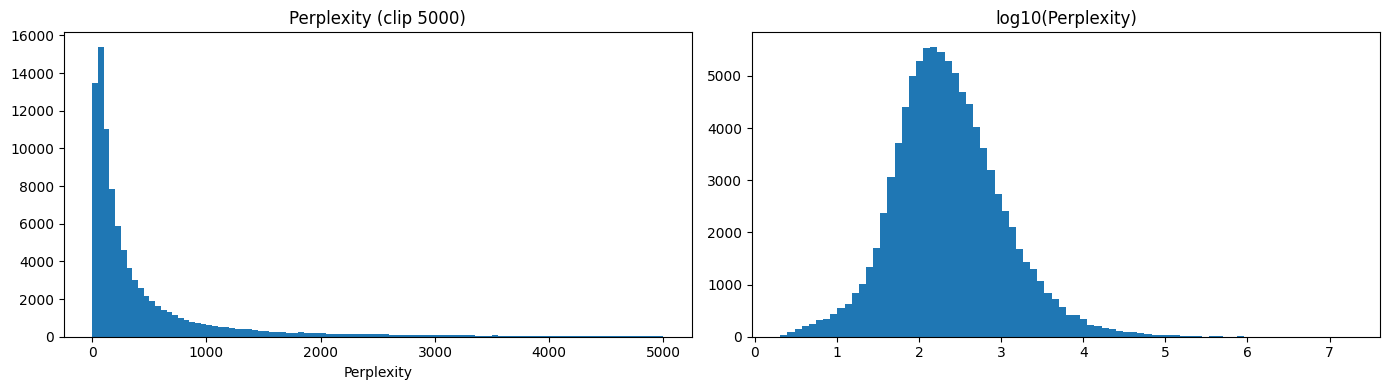

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("brainrot_corpus_ru_scored.parquet")
df_valid = df[df["perplexity"].notna()].copy()

# === Базовая статистика ===
print(f"📊 Статистика perplexity:")
print(df_valid["perplexity"].describe())

# === Распределение ===
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_valid["perplexity"], bins=100, range=(0, 5000))
axes[0].set_title("Perplexity (clip 5000)")
axes[0].set_xlabel("Perplexity")
axes[1].hist(np.log10(df_valid["perplexity"] + 1), bins=80)
axes[1].set_title("log10(Perplexity)")
plt.tight_layout()
plt.savefig("perplexity_distribution.png", dpi=100)
plt.show()

In [4]:
# ============================================================
# ВЫБОР ПОРОГА: статистика по лог-перплексии, только верхний хвост
# ============================================================
log_ppl = np.log10(df_valid["perplexity"] + 1)
mu, sigma = log_ppl.mean(), log_ppl.std()
print(f"log10(ppl): среднее={mu:.2f}, std={sigma:.2f}\n")

# Смотрим, что даёт каждый k — и в перплексии, и в количестве, и в доле
print(f"{'k':>4} | {'порог ppl':>10} | {'кандидатов':>10} | {'доля':>6}")
print("-" * 42)
for k in [1.0, 1.25, 1.5, 1.75, 2.0, 2.5]:
    thr = 10 ** (mu + k * sigma) - 1
    n = (df_valid["perplexity"] >= thr).sum()
    print(f"{k:>4} | {thr:>10.0f} | {n:>10} | {n/len(df_valid):>5.1%}")

log10(ppl): среднее=2.36, std=0.67

   k |  порог ppl | кандидатов |   доля
------------------------------------------
 1.0 |       1070 |      14052 | 14.6%
1.25 |       1574 |       9849 | 10.3%
 1.5 |       2315 |       6900 |  7.2%
1.75 |       3405 |       4687 |  4.9%
 2.0 |       5008 |       3181 |  3.3%
 2.5 |      10834 |       1458 |  1.5%


In [5]:
from sklearn.mixture import GaussianMixture

X = log_ppl.values.reshape(-1, 1)
gmm = GaussianMixture(n_components=2, random_state=42).fit(X)

# Компонента с большим средним = "аномальная"
order = np.argsort(gmm.means_.ravel())
normal_c, anom_c = order[0], order[1]

# Порог = граница, где апостериорная вероятность аномальной компоненты > 0.5
grid = np.linspace(log_ppl.min(), log_ppl.max(), 2000).reshape(-1, 1)
proba = gmm.predict_proba(grid)[:, anom_c]
cross = grid[np.argmax(proba > 0.5)][0]
thr_gmm = 10 ** cross - 1

n_gmm = (df_valid["perplexity"] >= thr_gmm).sum()
print(f"GMM-порог: ppl={thr_gmm:.0f} | кандидатов={n_gmm} ({n_gmm/len(df_valid):.1%})")

GMM-порог: ppl=660 | кандидатов=21133 (22.0%)


In [1]:
import sys
!{sys.executable} -m pip install --default-timeout=120 pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 31.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pymorphy3]

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
from collections import defaultdict
from transformers import AutoTokenizer

# ============================================================
# КОРПУС АНОМАЛИЙ + ИЗВЛЕЧЕНИЕ АНОМАЛЬНЫХ СЛОВ
# ============================================================

# --- Шаг 1: выделяем датасет аномалий по GMM-порогу ---
THRESHOLD = 660
df_anom = df_valid[df_valid["perplexity"] >= THRESHOLD].copy()
print(f"Аномальных комментариев: {len(df_anom)}")

# --- Шаг 2: токенизатор нужен, чтобы раскодировать byte-level BPE в буквы ---
tokenizer = AutoTokenizer.from_pretrained("ai-forever/rugpt3small_based_on_gpt2")

def decode_token(tok):
    # Один BPE-токен -> читаемая строка (убирает мойибаке и маркер пробела)
    try:
        return tokenizer.convert_tokens_to_string([tok]).strip()
    except Exception:
        return ""

Аномальных комментариев: 21139


config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.25k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.71M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.27M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

In [15]:
# --- Шаг 3: разбираем top_surprising_tokens в плоский список (слово, удивление, id коммента) ---
records = []
for doc_id, raw in zip(df_anom.index, df_anom["top_surprising_tokens"]):
    if not isinstance(raw, str) or not raw:
        continue
    for item in raw.split("|"):
        if ":" not in item:
            continue
        tok, nll = item.rsplit(":", 1)
        try:
            nll = float(nll)
        except ValueError:
            continue
        word = decode_token(tok).lower()
        records.append((word, nll, doc_id))

tok_df = pd.DataFrame(records, columns=["word", "surprisal", "doc_id"])
print(f"Сырых удивительных токенов: {len(tok_df)}")

Сырых удивительных токенов: 96554


In [16]:
# --- Шаг 4: фильтрация мусора ---
def is_real_word(w):
    if len(w) < 2:
        return False
    if not any(ch.isalpha() for ch in w):   # отсекаем пунктуацию и числа
        return False
    return True

tok_df = tok_df[tok_df["word"].map(is_real_word)].copy()
print(f"После чистки: {len(tok_df)}")

После чистки: 75278


In [17]:
# --- Шаг 5: агрегируем в корпус аномальных слов ---
corpus = (
    tok_df.groupby("word")
    .agg(doc_freq=("doc_id", "nunique"),
         mean_surprisal=("surprisal", "mean"),
         max_surprisal=("surprisal", "max"))
    .reset_index()
    .sort_values("doc_freq", ascending=False)
)

print(f"\nУникальных аномальных слов: {len(corpus)}")
print("\nТоп-30 по частоте появления в аномалиях:")
print(corpus.head(30).to_string(index=False))

# --- Шаг 6: сохраняем ---
df_anom.to_parquet("brainrot_anomalies.parquet", index=False)
corpus.to_csv("brainrot_anomalous_words.csv", index=False)
print("\nСохранено: brainrot_anomalies.parquet, brainrot_anomalous_words.csv")


Уникальных аномальных слов: 12464

Топ-30 по частоте появления в аномалиях:
  word  doc_freq  mean_surprisal  max_surprisal
    ми       539       10.260678          17.08
   это       513        8.216983          17.25
   пик       391       11.777079          19.34
    не       386        5.743979          19.65
    ro       337        7.308450          16.78
    ро       305        9.823901          17.08
    на       297        6.316275          16.53
    ri       295       10.928771          20.29
    то       277        7.683011          17.07
    ты       269        8.866044          18.86
   bro       251       11.840553          19.73
    да       244        9.037056          17.83
    ба       240        8.102863          20.36
крокод       235       13.250464          19.56
    он       234        8.347319          17.70
    is       233        7.384068          13.79
    ка       232        7.101202          14.60
    zz       226        8.734286          17.22
  real     

In [7]:
import torch, numpy as np, pandas as pd, re
from collections import defaultdict
from transformers import AutoTokenizer, AutoModelForCausalLM

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
tok = AutoTokenizer.from_pretrained("ai-forever/rugpt3small_based_on_gpt2")
model = AutoModelForCausalLM.from_pretrained("ai-forever/rugpt3small_based_on_gpt2").to(DEVICE).eval()

@torch.no_grad()
def word_surprisals(text, max_length=256):
    enc = tok(text, return_tensors="pt", truncation=True, max_length=max_length)
    ids = enc["input_ids"].to(DEVICE)
    if ids.shape[1] < 2:
        return []
    logits = model(ids).logits
    logp = torch.log_softmax(logits[0, :-1], dim=-1)
    nll_tail = -logp.gather(1, ids[0, 1:].unsqueeze(-1)).squeeze(-1).cpu().numpy()

    full_ids = ids[0].tolist()                       # ВСЕ токены, включая нулевой
    pieces   = tok.convert_ids_to_tokens(full_ids)
    nll_full = np.concatenate([[0.0], nll_tail])     # первому токену surprisal=0

    words, cur_ids, cur_nll = [], [], 0.0
    for tid, piece, s in zip(full_ids, pieces, nll_full):
        if piece.startswith("Ġ") and cur_ids:        # начало нового слова
            words.append((tok.decode(cur_ids).strip(), cur_nll))
            cur_ids, cur_nll = [], 0.0
        cur_ids.append(tid)
        cur_nll += float(s)
    if cur_ids:
        words.append((tok.decode(cur_ids).strip(), cur_nll))
    return words

pytorch_model.bin:   0%|          | 0.00/551M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: ai-forever/rugpt3small_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/551M [00:00<?, ?B/s]

In [8]:
from tqdm.auto import tqdm
import pymorphy3
pmorph = pymorphy3.MorphAnalyzer()
CLEAN = re.compile(r"[^а-яёa-z\-]")

word_nll, word_docs = defaultdict(list), defaultdict(set)
for doc_id, text in tqdm(zip(df_anom.index, df_anom["text"]), total=len(df_anom)):
    if not isinstance(text, str):
        continue
    for word, s in word_surprisals(text):
        w = CLEAN.sub("", word.lower().strip())
        if len(w) < 3:
            continue
        word_nll[w].append(s)
        word_docs[w].add(doc_id)

corpus = pd.DataFrame([
    {"word": w, "doc_freq": len(word_docs[w]),
     "mean_surprisal": float(np.mean(word_nll[w]))}
    for w in word_nll
])

def classify(word, doc_freq):
    parses = pmorph.parse(word)
    in_dict = any(p.is_known for p in parses)
    if re.search("[a-z]", word):                  # латиница (en_brainrot)
        return pd.Series({"lemma": word, "kind": "lat"})
    if in_dict:                                   # обычное русское → лемматизируем
        return pd.Series({"lemma": parses[0].normal_form, "kind": "ru_dict"})
    if doc_freq <= 6:                             # редкое + не в словаре → вероятно огрызок
        return pd.Series({"lemma": word, "kind": "fragment?"})
    return pd.Series({"lemma": word, "kind": "slang"})   # частое не-словарное → сленг

corpus[["lemma", "kind"]] = corpus.apply(lambda r: classify(r["word"], r["doc_freq"]), axis=1)

# выкидываем подозрительные огрызки и слишком "скучные" слова
corpus = corpus[(corpus["kind"] != "fragment?") & (corpus["mean_surprisal"] >= 9)]

# схлопываем формы одного слова по лемме; lemma делаем главным ключом "word"
agg = (corpus.groupby("lemma")
       .agg(forms=("word", lambda x: " / ".join(sorted(set(x)))),
            doc_freq=("doc_freq", "sum"),
            mean_surprisal=("mean_surprisal", "mean"),
            kind=("kind", "first"))
       .reset_index()
       .rename(columns={"lemma": "word"})
       .sort_values("doc_freq", ascending=False))

corpus = agg                      # дальше по ноутбуку всё работает на corpus["word"]
print(corpus["kind"].value_counts())
print(corpus.head(40).to_string(index=False))
corpus.to_csv("brainrot_words_clean.csv", index=False)

  0%|          | 0/21139 [00:00<?, ?it/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


kind
ru_dict    5883
lat        4666
slang       198
Name: count, dtype: int64
     word                                                                                                       forms  doc_freq  mean_surprisal    kind
    пикми                                                                                                       пикми       408       23.883571   slang
     real                                                                                                        real       253       10.805467     lat
    fanum                                                                                                       fanum       227       16.675107     lat
      мем                                    мем / мема / мемам / мемами / мемах / меме / мемов / мемом / мему / мемы       220       13.834500 ru_dict
     rizz                                                                                                        rizz       216       19.916293     lat
  skibidi

In [39]:
corpus

,word,forms,doc_freq,mean_surprisal,kind
8214,пикми,пикми,408,23.883571,slang
3158,real,real,253,10.805467,lat
1301,fanum,fanum,227,16.675107,lat
7173,мем,мем / мема / мемам / мемами / мемах / меме / м...,220,13.834500,ru_dict
3276,rizz,rizz,216,19.916293,lat
...,...,...,...,...,...
5448,вырубить,вырубит,1,15.801299,ru_dict
5446,вырезка,вырезки,1,14.919874,ru_dict
5444,вырваться,вырвалось,1,15.627147,ru_dict
5443,вырвать,вырвал,1,10.003716,ru_dict


In [15]:
corpus[corpus["kind"] == "slang"].sort_values("doc_freq", ascending=False) \
    .to_csv("slang_for_manual.csv", index=False, encoding="utf-8-sig")

In [13]:
!pip install wordfreq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 MB 40.3 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [wordfreq]

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [14]:
from wordfreq import zipf_frequency
def is_common_english(w):
    return bool(re.fullmatch("[a-z]+", w)) and zipf_frequency(w, "en") >= 3.5

lat = corpus[corpus["kind"] == "lat"].copy()
lat["is_meme"] = ~lat["word"].map(is_common_english)
print(lat[lat["is_meme"]].head(40).to_string(index=False))  # только мемы

      word      forms  doc_freq  mean_surprisal kind  is_meme
     fanum      fanum       227       16.675107  lat     True
      rizz       rizz       216       19.916293  lat     True
   skibidi    skibidi       192       27.081355  lat     True
  brainrot   brainrot       111       26.262417  lat     True
     sybau      sybau        94       28.873083  lat     True
       ngl        ngl        88       16.627362  lat     True
      tuff       tuff        81       17.294718  lat     True
    mewing     mewing        77       22.229136  lat     True
  gigachad   gigachad        75       28.302338  lat     True
       pov        pov        57       10.446067  lat     True
   tralala    tralala        48       19.461265  lat     True
     gronk      gronk        47       24.305211  lat     True
       mew        mew        40       17.752142  lat     True
    lowkey     lowkey        38       20.579193  lat     True
   deadass    deadass        37       27.164874  lat     True
 tralale

In [38]:
import re
word = "холли"
pat = re.compile(re.escape(word), re.IGNORECASE)
hits = [t for t in df_anom["text"] if isinstance(t, str) and pat.search(t)]
for h in hits[:10]:
    print("—", h[:200])

— До чего Холли бам докатился
— 0:09 с крутым папой холли бам поссорился
— Холли бам сделай 2 часть песня огонь
— Холли бам спасибо за детство
— Я обещал что у Холли бама будет 10 млн в конце августа почти
— ухх эдит от Холли бама
— Холлибо ты самый лучший ещё ты самый везучий
— Холли бам ты лучше всех до этого был А4 теперь
— Вы согласны что Холли бама лучший ❤
— Холли Буба


In [68]:
corpus = corpus[~corpus.word.str.startswith('-')]

In [73]:
import pandas as pd, numpy as np, re

slang = pd.read_csv("slang_with_pos.csv", sep=';')

def join_forms(series):
    parts = []
    for v in series.dropna():
        parts += [f.strip() for f in str(v).split("/")]
    return " / ".join(sorted(set(p for p in parts if p)))

slang_agg = (slang.groupby("canonical").agg(
    forms=("forms", join_forms),
    doc_freq=("doc_freq", "sum"),
    mean_surprisal=("mean_surprisal", "mean"),
    pos=("pos", "first"),
    kind=("kind", "first"),
).reset_index().rename(columns={"canonical": "word"}))
print(f"Сленг после схлопывания: {len(slang_agg)} (было строк: {len(slang)})")

Сленг после схлопывания: 126 (было строк: 171)


In [78]:
from wordfreq import zipf_frequency   # pip install wordfreq при необходимости
import re

def is_common_en(w):
    # частотное английское слово = шум; редкое (rizz, skibidi) = мем, оставляем
    return bool(re.fullmatch(r"[a-z]+", str(w))) and zipf_frequency(str(w), "en") >= 3.5

# ── 2. ru_dict и очищенный lat из corpus ───────────────────────
other = corpus[corpus["kind"].isin(["ru_dict", "lat"])].copy()
drop = (other["kind"] == "lat") & other["word"].map(is_common_en)
print(f"Выкинуто частотного английского: {drop.sum()}")
other = other[~drop]
if "pos" not in other: other["pos"] = ""
keep = ["word", "forms", "doc_freq", "mean_surprisal", "pos", "kind"]
other = other[[c for c in keep if c in other.columns]]

Выкинуто частотного английского: 1452


In [79]:
lexicon = pd.concat([slang_agg[keep], other], ignore_index=True)
lexicon = lexicon.drop_duplicates("word").sort_values("doc_freq", ascending=False)
print(f"Всего единиц в лексиконе: {len(lexicon)}")
print(lexicon["kind"].value_counts())


Всего единиц в лексиконе: 9211
kind
ru_dict    5883
lat        3202
slang       126
Name: count, dtype: int64


In [81]:
texts_all = df_anom["text"].tolist()
def find_examples(forms_str, n=3):
    forms = [f.strip() for f in str(forms_str).split("/") if f.strip()]
    if not forms: return ""
    pat = re.compile(r"(?:^|\W)(" + "|".join(re.escape(f) for f in forms) + r")(?:\W|$)", re.I)
    hits = [t for t in texts_all if isinstance(t, str) and pat.search(t)]
    return " ||| ".join(h[:200] for h in hits[:n])

lexicon["examples"] = lexicon["forms"].apply(find_examples)

In [82]:
cols = ["word", "forms", "kind", "pos", "doc_freq", "mean_surprisal", "examples"]
lexicon = lexicon[[c for c in cols if c in lexicon.columns]]
lexicon.to_csv("lexicon_final.csv", index=False, encoding="utf-8-sig")
print(f"Готово: {len(lexicon)} единиц → lexicon_final.csv")

Готово: 9211 единиц → lexicon_final.csv


In [88]:
import re, pandas as pd
import pymorphy3
morph = pymorphy3.MorphAnalyzer()

POS_MAP = {
    'NOUN':'сущ.', 'ADJF':'прил.', 'ADJS':'прил.', 'COMP':'компаратив',
    'VERB':'глаг.', 'INFN':'глаг.', 'PRTF':'прич.', 'PRTS':'прич.',
    'GRND':'дееприч.', 'NUMR':'числит.', 'ADVB':'нареч.', 'NPRO':'местоим.',
    'PRED':'предик.', 'PREP':'предлог', 'CONJ':'союз', 'PRCL':'частица', 'INTJ':'межд.'
}

def detect_pos(word):
    w = str(word).lower()
    if re.search(r'[a-z]', w) and not re.search(r'[а-яё]', w):
        return 'eng'                       # чисто латинское — отдельно
    tag = morph.parse(w)[0].tag.POS
    return POS_MAP.get(tag, '') if tag else ''

# заполняем ТОЛЬКО пустые pos, ручной slang не перезаписываем
mask = lexicon['pos'].fillna('') == ''
lexicon.loc[mask, 'pos'] = lexicon.loc[mask, 'word'].map(detect_pos)

print(lexicon['pos'].value_counts())

pos
сущ.          3559
eng           2701
глаг.         1575
прил.          770
нареч.         293
               119
межд.           46
имя             37
союз            31
дееприч.        17
числит.         15
местоим.        14
частица         12
прич.            8
предлог          8
предик.          3
вводн.           2
компаратив       1
Name: count, dtype: int64


In [91]:
import re
from wordfreq import zipf_frequency

# твой готовый список маркеров из ячеек 3-4 (en_brainrot и т.п.)
KNOWN = set(m.lower() for m in ALL_LATIN_MARKERS)   # подставь своё имя переменной

def lat_verdict(w):
    w = str(w).lower()
    # 1. мешанина алфавитов → ник/склейка
    if re.search(r'[a-z]', w) and re.search(r'[а-яё]', w):
        return 'junk'
    # 2. цифры/дефисы-хвосты/длина → хэндлы и шум
    if re.search(r'\d', w) or len(w) > 14:
        return 'junk'
    # 3. растянутые буквы (gyattttt, realllll) → нормализуем, но помечаем
    if re.search(r'(.)\1\1', w):
        return 'junk'
    # 4. известный мем → оставляем
    if w in KNOWN:
        return 'meme'
    # 5. валидное английское слово (заимствование) → на ревью
    if zipf_frequency(w, 'en') >= 2.0:
        return 'review'
    return 'junk'

lat = lexicon[lexicon['kind'] == 'lat'].copy()
lat['verdict'] = lat['word'].map(lat_verdict)
print(lat['verdict'].value_counts())

# оставляем только мемы (+ при желании review), junk выкидываем
lat_clean = lat[lat['verdict'].isin(['meme', 'review'])]
print(f"\nИз {len(lat)} осталось {len(lat_clean)}")
print(sorted(lat_clean['word'].tolist()))

verdict
junk      2508
review     632
meme        62
Name: count, dtype: int64

Из 3202 осталось 694
['aah', 'abt', 'accidently', 'acm', 'addicting', 'agents-td', 'aight', 'aint', 'airhead', 'akash', 'alfa', 'alight', 'alpha-', 'alphas', 'amogus', 'andrey', 'anim', 'annoys', 'antics', 'apk', 'aria-na-', 'ascended', 'asf', 'asl', 'asli', 'asmr', 'asparagus', 'astro', 'auntie', 'aways', 'awh', 'ayo', 'ayy', 'badd', 'baddest', 'baka', 'ballerina', 'banger', 'barkley', 'barley', 'bateman', 'bcs', 'bein', 'besties', 'betas', 'betta', 'better-', 'bir', 'birdman', 'birthdays', 'black-', 'blackjack', 'bloodline', 'blud', 'blushed', 'blushing', 'boi', 'bola', 'bombardino', 'bombardiro', 'bombombini', 'boomer', 'bop', 'bos', 'braindead', 'brainrot', 'brb', 'bri', 'bron', 'broom', 'brr', 'bru', 'bruv', 'bts', 'bulky', 'burrito', 'bussin', 'bux', 'cad', 'caine', 'calisthenics', 'cameraman', 'cameramen', 'capon', 'capping', 'cappuccino', 'cardi', 'carrey', 'caveman', 'cayman', 'cee', 'cee-alright',

In [92]:
# verdict уже посчитан на lat; перенесём его в lexicon и почистим
lexicon["verdict"] = ""
lat_mask = lexicon["kind"] == "lat"
lexicon.loc[lat_mask, "verdict"] = lexicon.loc[lat_mask, "word"].map(lat_verdict)

before = len(lexicon)
# выкидываем только lat+junk; ru_dict и slang не трогаем
drop = (lexicon["kind"] == "lat") & (lexicon["verdict"] == "junk")
lexicon_clean = lexicon[~drop].copy()

print(f"Выкинуто junk: {drop.sum()}")
print(f"Было {before} → стало {len(lexicon_clean)}")
print(lexicon_clean["kind"].value_counts())

# сохраним промежуточно
lexicon_clean.to_csv("lexicon_clean.csv", index=False, encoding="utf-8-sig")

Выкинуто junk: 2508
Было 9211 → стало 6703
kind
ru_dict    5883
lat         694
slang       126
Name: count, dtype: int64


In [94]:
lexicon_clean

,word,forms,kind,pos,doc_freq,mean_surprisal,examples,verdict
82,пикми,пикми / пикмуха,slang,сущ.,415,25.562486,Ксюша больше приходит в отличной с Настей кото...,
126,fanum,fanum,lat,eng,227,16.675107,Fanum be the fkn kool aid man ||| He ain't fan...,meme
127,мем,мем / мема / мемам / мемами / мемах / меме / м...,ru_dict,сущ.,220,13.834500,"Это мем 2019, лол ​@ОльгаГусева-й8л ||| Это лу...",
128,rizz,rizz,lat,eng,216,19.916293,Bro has rizz ||| ey ey 6 7 in rizz ||| I’mma B...,meme
129,skibidi,skibidi,lat,eng,192,27.081355,Atleast let's just bring skibidi toilet back🥀🙏...,meme
...,...,...,...,...,...,...,...,...
5290,раздавать,раздаёт,ru_dict,глаг.,1,14.569279,Каменный батя раздаёт лещей на карте,
5289,раздавить,раздавить,ru_dict,глаг.,1,10.762434,Нам титан камера Мэн 3.0 чтобы раздавить его руки,
5288,cheese-king,cheese-king,lat,eng,1,43.841292,,review
5287,разделиться,разделились,ru_dict,глаг.,1,15.564113,А что вы чужим бабки разделились хочу балерина,


In [96]:
!pip install openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openai]2m1/2 [openai]

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [103]:
!pip install yandex-gpt-api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [yandex-gpt-api]

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [132]:
import sys
!{sys.executable} -m pip install --default-timeout=120 mistralai


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [134]:
!pip install --upgrade --force-reinstall --default-timeout=120 mistralai

  Using cached mistralai-2.4.12-py3-none-any.whl.metadata (67 kB)
  Using cached eval_type_backport-0.4.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jsonpath_python-1.1.6-py3-none-any.whl.metadata (17 kB)
  Using cached opentelemetry_api-1.42.1-py3-none-any.whl.metadata (1.4 kB)
  Using cached opentelemetry_semantic_conventions-0.60b1-py3-none-any.whl.metadata (2.4 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached opentelemetry_api-1.39.1-py3-none-any.whl.metadata (1.5 kB)
  Using cached pydantic_core-2.46.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (6.6 kB)
Using cached mistralai-2.4.12-py3-none-any.whl (1.2 MB)
Using cached opentelemetry_semantic_conventions-0.60b1-py3-none-any.whl (219 kB)
Using cached opentelemetry_api-1.39.1-py3-none-any.whl (66 kB)
Using cached eval_type_backport-0.4.0-py3-none-any.whl 

In [136]:
from mistralai.client import Mistral
import json, time, pandas as pd

client = Mistral(api_key="")   # ключ с console.mistral.ai, experiment-тир
MODEL = "mistral-small-latest"

definitions = {}   # кэш слово -> результат, переживает повторный запуск ячейки

def explain(word, examples):
    ex = "\n".join(f"- {e[:200]}" for e in examples if e)
    prompt = (
        f'Слово из русскоязычных интернет-комментариев: "{word}".\n'
        f'Примеры употребления:\n{ex}\n\n'
        f'Определи значение ТОЛЬКО по примерам. Ответь строго JSON без markdown:\n'
        f'{{"meaning":"значение в 1-2 предложениях по-русски",'
        f'"pos":"часть речи","origin":"происхождение если ясно",'
        f'"register":"мем/сленг/нейтральное"}}\n'
        f'Если из примеров значение неясно — meaning:"неясно".'
    )
    r = client.chat.complete(
        model=MODEL, max_tokens=250,
        messages=[{"role": "user", "content": prompt}],
    )
    txt = r.choices[0].message.content.strip().strip("`").lstrip("json").strip()
    try:
        return {"word": word, **json.loads(txt)}
    except Exception:
        return {"word": word, "meaning": txt[:200]}

def run(df_subset, sleep=1.0):
    for i, row in enumerate(df_subset.itertuples()):
        if row.word in definitions:
            continue
        ex = str(row.examples).split(" ||| ") if pd.notna(row.examples) else []
        try:
            definitions[row.word] = explain(row.word, ex)
        except Exception as e:
            print(f"  ✗ {row.word}: {e}")
            time.sleep(5); continue          # rate-limit — ждём подольше
        if (i + 1) % 20 == 0:
            print(f"  {i+1}/{len(df_subset)}  (всего в кэше: {len(definitions)})")
        time.sleep(sleep)

In [137]:
# Этап 1: сленг (твоё ядро, ~126 слов) — здесь контекст из примеров критичен
run(lexicon_clean[lexicon_clean["kind"] == "slang"])
pd.DataFrame(definitions.values()).to_csv("defs_slang.csv", index=False, encoding="utf-8-sig")
print(pd.DataFrame(definitions.values())[["word","meaning","pos"]].head(30).to_string())

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/mistralai/client/models/chatcompletionrequest.py:258: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue: Expected `str` but got `Unset` with value `Unset()` - serialized value may not be as expected
  PydanticSerializationUnexpectedValue: Expected `list[str]` but got `Unset` with value `Unset()` - serialized value may not be as expected
  PydanticSerializationUnexpectedValue: Expected `literal['none','minimal','low','medium','high','xhigh']` but got `Unset` with value `Unset()` - serialized value may not be as expected
  PydanticSerializationUnexpectedValue: Expected `none` but got `Unset` with value `Unset()` - serialized value may not be as expected
  PydanticSerializationUnexpectedValue: Expected `literal['reasoning']` but got `Unset` with value `Unset()` - serialized value may not be as expected
  PydanticSerializationUnexpectedValue: Expected `none` but got `Unset` with 

  20/126  (всего в кэше: 20)
  40/126  (всего в кэше: 40)
  60/126  (всего в кэше: 60)
  80/126  (всего в кэше: 80)
  100/126  (всего в кэше: 100)
  120/126  (всего в кэше: 120)
          word                                                                                                                                                                                                    meaning                                                              pos
0        пикми                                                                                                                     что-то положительное, хорошее, вероятно связанное с внешностью или характером человека                               существительное или прилагательное
1     брейнрот                                                                        шутливое или ироничное название для нелепого, бессмысленного или неправильного продолжения текста, часто с искажением слов или фраз                                       

In [139]:
# Этап 2 — английские мемы (meme+review, ~694), заодно pos
run(lexicon_clean[(lexicon_clean["kind"]=="lat") & (lexicon_clean["verdict"].isin(["meme","review"]))])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/mistralai/client/models/chatcompletionrequest.py:258: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue: Expected `str` but got `Unset` with value `Unset()` - serialized value may not be as expected
  PydanticSerializationUnexpectedValue: Expected `list[str]` but got `Unset` with value `Unset()` - serialized value may not be as expected
  PydanticSerializationUnexpectedValue: Expected `literal['none','minimal','low','medium','high','xhigh']` but got `Unset` with value `Unset()` - serialized value may not be as expected
  PydanticSerializationUnexpectedValue: Expected `none` but got `Unset` with value `Unset()` - serialized value may not be as expected
  PydanticSerializationUnexpectedValue: Expected `literal['reasoning']` but got `Unset` with value `Unset()` - serialized value may not be as expected
  PydanticSerializationUnexpectedValue: Expected `none` but got `Unset` with 

  20/694  (всего в кэше: 146)
  40/694  (всего в кэше: 166)
  60/694  (всего в кэше: 186)
  80/694  (всего в кэше: 206)
  100/694  (всего в кэше: 226)
  120/694  (всего в кэше: 246)
  140/694  (всего в кэше: 266)
  160/694  (всего в кэше: 286)
  180/694  (всего в кэше: 306)
  200/694  (всего в кэше: 326)
  220/694  (всего в кэше: 346)
  240/694  (всего в кэше: 366)
  260/694  (всего в кэше: 386)
  280/694  (всего в кэше: 406)
  300/694  (всего в кэше: 426)
  320/694  (всего в кэше: 446)
  340/694  (всего в кэше: 466)
  360/694  (всего в кэше: 486)
  380/694  (всего в кэше: 506)
  400/694  (всего в кэше: 526)
  420/694  (всего в кэше: 546)
  440/694  (всего в кэше: 566)
  460/694  (всего в кэше: 586)
  480/694  (всего в кэше: 606)
  500/694  (всего в кэше: 626)
  520/694  (всего в кэше: 646)
  540/694  (всего в кэше: 666)
  560/694  (всего в кэше: 686)
  580/694  (всего в кэше: 706)
  600/694  (всего в кэше: 726)
  620/694  (всего в кэше: 746)
  640/694  (всего в кэше: 766)
  660/694  (

In [156]:
for i in lexicon_clean[lexicon_clean["kind"] == "ru_dict"].word.unique():
    if i in ALL_CYRILLIC_MARKERS:
        print("'" + i + "'", end=', ')

'сигма', 'база', 'пик', 'краш', 'альфа', 'флекс', 'бета', 'альт', 'пиковый', 'плов', 'анк', 'кап', 'тащить', 'мид', 'черемша', 

In [158]:
memes_rus = lexicon_clean[lexicon_clean.word.isin(['сигма', 'база', 'пик', 'краш', 'альфа', 'флекс', 'бета', 'альт', 'пиковый', 'плов', 'анк', 'кап', 'тащить', 'мид', 'черемша'])]
run(memes_rus)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/mistralai/client/models/chatcompletionrequest.py:258: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue: Expected `str` but got `Unset` with value `Unset()` - serialized value may not be as expected
  PydanticSerializationUnexpectedValue: Expected `list[str]` but got `Unset` with value `Unset()` - serialized value may not be as expected
  PydanticSerializationUnexpectedValue: Expected `literal['none','minimal','low','medium','high','xhigh']` but got `Unset` with value `Unset()` - serialized value may not be as expected
  PydanticSerializationUnexpectedValue: Expected `none` but got `Unset` with value `Unset()` - serialized value may not be as expected
  PydanticSerializationUnexpectedValue: Expected `literal['reasoning']` but got `Unset` with value `Unset()` - serialized value may not be as expected
  PydanticSerializationUnexpectedValue: Expected `none` but got `Unset` with 

In [159]:
defs_df = pd.DataFrame(definitions.values())

In [160]:
defs_df

,word,meaning,pos,origin,register
0,пикми,"что-то положительное, хорошее, вероятно связан...",существительное или прилагательное,неясно,мем/сленг
1,брейнрот,"шутливое или ироничное название для нелепого, ...",существительное,искажение английского 'brain rot' (буквально '...,мем/сленг
2,тралала,неясно,неясно,неясно,мем/сленг
3,крокодило,"что-то, что вызывает недоумение, выглядит стра...",существительное или прилагательное (в зависимо...,"вероятно, мемное искажение слова 'крокодил' в ...",мем/сленг
4,тралалело,неясно,неясно,неясно,мем/сленг
...,...,...,...,...,...
830,анк,неясно,неясно,неясно,неясно
831,кап,неясно,неизвестно,неясно,неясно
832,тащить,"уничижительное название человека, который выпо...",существительное (в именительном падеже),"от глагола 'тащить' в значении 'тянуть, выполн...",мем/сленг
833,мид,"грубое оскорбление в адрес собеседника, подраз...",существительное (обращение),сокращение от слова 'мидвайт' (midwit) — интер...,мем/сленг


In [161]:
defs_df = pd.DataFrame(definitions.values())
final = lexicon_clean.merge(defs_df, on="word", how="left", suffixes=("", "_llm"))
final.to_csv("lexicon_with_defs.csv", index=False, encoding="utf-8-sig")
print(f"С определениями: {final['meaning'].notna().sum()} из {len(final)}")

С определениями: 835 из 6703


In [165]:
final

,word,forms,kind,pos,doc_freq,mean_surprisal,examples,verdict,meaning,pos_llm,origin,register
0,пикми,пикми / пикмуха,slang,сущ.,415,25.562486,Ксюша больше приходит в отличной с Настей кото...,,"что-то положительное, хорошее, вероятно связан...",существительное или прилагательное,неясно,мем/сленг
1,fanum,fanum,lat,eng,227,16.675107,Fanum be the fkn kool aid man ||| He ain't fan...,meme,"Шутливое обозначение ситуации, когда кто-то не...",существительное (в роли мема),"от имени стримера и ютубера Fanum (Фанум), изв...",мем/сленг
2,мем,мем / мема / мемам / мемами / мемах / меме / м...,ru_dict,сущ.,220,13.834500,"Это мем 2019, лол ​@ОльгаГусева-й8л ||| Это лу...",,NaN,NaN,NaN,NaN
3,rizz,rizz,lat,eng,216,19.916293,Bro has rizz ||| ey ey 6 7 in rizz ||| I’mma B...,meme,"умение нравиться, привлекательность, харизма, ...",существительное,"английское (от ""charisma"")",мем/сленг
4,skibidi,skibidi,lat,eng,192,27.081355,Atleast let's just bring skibidi toilet back🥀🙏...,meme,"шутливое или ироничное название туалета, испол...",существительное,"мема из интернет-культуры, возможно связано с ...",мем/сленг
...,...,...,...,...,...,...,...,...,...,...,...,...
6698,раздавать,раздаёт,ru_dict,глаг.,1,14.569279,Каменный батя раздаёт лещей на карте,,NaN,NaN,NaN,NaN
6699,раздавить,раздавить,ru_dict,глаг.,1,10.762434,Нам титан камера Мэн 3.0 чтобы раздавить его руки,,NaN,NaN,NaN,NaN
6700,cheese-king,cheese-king,lat,eng,1,43.841292,,review,"о человеке, который считает себя лучшим или пр...",существительное,английское слово 'cheese' (сыр) + 'king' (коро...,мем/сленг
6701,разделиться,разделились,ru_dict,глаг.,1,15.564113,А что вы чужим бабки разделились хочу балерина,,NaN,NaN,NaN,NaN


In [163]:
final.pos.unique()

array(['сущ.', 'eng', 'имя', 'прил.', 'глаг.', '', 'нареч.', 'частица',
       'предик.', 'дееприч.', 'межд.', 'союз', 'прич.', 'местоим.',
       'предлог', 'числит.', 'вводн.'], dtype=object)

In [164]:
final.pos_llm.unique()

array(['существительное или прилагательное',
       'существительное (в роли мема)', nan, 'существительное', 'неясно',
       'существительное или прилагательное (в зависимости от контекста)',
       'прилагательное (в роли сказуемого)',
       'существительное (в значении мема)', 'междометие',
       'междометие/обращение', 'существительное или междометие',
       'междометие/частица (в составе фразы)',
       'существительное/прилагательное (в зависимости от контекста)',
       'вводное слово/фраза', 'прилагательное', 'частица/вводное слово',
       'частица или междометие', 'междометие/частица',
       'существительное (прозвище)', 'существительное (имя собственное)',
       'наречие', 'прилагательное (в значении усилителя)',
       'существительное (обращение)', 'междометие/существительное',
       'глагол', 'глагол (в форме прошедшего времени)',
       'междометие/вводное слово', 'прилагательное/наречие',
       'часть речи (отрицательная форма глагола)', 'глагол (причастие)',
   

In [166]:
import re, numpy as np, pandas as pd

def normalize_pos(raw):
    if not isinstance(raw, str) or not raw.strip():
        return ""
    s = raw.lower()
    # отрезаем уточнения в скобках и берём часть до первого разделителя
    s = re.sub(r"\(.*?\)", " ", s)
    head = re.split(r"[/,]| или | в роли | в значении | в форме ", s)[0].strip()

    # порядок матчинга = приоритет (специфичное раньше общего)
    if re.search(r"неясн|неизвест|неопредел|вероятно", s):    return "неясно"
    if re.search(r"деепричаст", head):                        return "дееприч."
    if re.search(r"причаст", head):                           return "прич."
    if re.search(r"существ|сущ\.|нарицательн|собственн|имя",  head): return "сущ."
    if re.search(r"прилагат|прил\.", head):                   return "прил."
    if re.search(r"глаг|инфинитив|императив|модальн.*глаг",    head): return "глаг."
    if re.search(r"нареч", head):                             return "нареч."
    if re.search(r"местоим", head):                           return "мест."
    if re.search(r"числит", head):                            return "числит."
    if re.search(r"междомет", head):                          return "межд."
    if re.search(r"частиц", head):                            return "частица"
    if re.search(r"предлог", head):                           return "предлог"
    if re.search(r"союз", head):                              return "союз"
    if re.search(r"вводн", head):                             return "вводн."
    if re.search(r"предикат|сказуем", head):                  return "предик."
    if re.search(r"аффикс|суффикс|приставк|префикс|часть слож|часть составн", head): return "аффикс"
    if re.search(r"сокращ|аббревиат", head):                  return "сущ."   # сокращения трактуем как сущ.
    return "неясно"

final["pos_llm_norm"] = final["pos_llm"].map(normalize_pos)
print(final["pos_llm_norm"].value_counts(dropna=False))

pos_llm_norm
           5868
сущ.        316
неясно      226
межд.       114
глаг.        66
прил.        54
нареч.       24
частица      18
мест.        10
аффикс        2
вводн.        1
союз          1
предлог       1
прич.         1
предик.       1
Name: count, dtype: int64


In [167]:
chk = (final[["pos_llm","pos_llm_norm"]]
       .drop_duplicates().sort_values("pos_llm_norm"))
print(chk.to_string(index=False))

                                                                                     pos_llm pos_llm_norm
                                                                                         NaN             
                                                                суффикс/часть сложного слова       аффикс
                                                              приставка/часть сложного слова       аффикс
                                                                         вводное слово/фраза       вводн.
                                                                 местоимение + глагол-связка        глаг.
                                                                          глагол (причастие)        глаг.
                                                                 модальный глагол/сокращение        глаг.
                                                                    глагол (вспомогательный)        глаг.
                                              

In [168]:
need = final["pos"].fillna("").isin(["", "eng"])
final.loc[need, "pos"] = final.loc[need, "pos_llm_norm"]

# если после этого осталось пусто (LLM тоже не определил) — ставим явное "неясно"
final["pos"] = final["pos"].replace("", "неясно")

print(final["pos"].value_counts())
final.to_csv("lexicon_final_pos.csv", index=False, encoding="utf-8-sig")

pos
сущ.        3585
глаг.       1571
прил.        759
нареч.       296
неясно       193
межд.        140
имя           37
союз          31
частица       27
числит.       15
местоим.      13
мест.         10
предлог        9
предик.        4
прич.          4
дееприч.       4
вводн.         3
аффикс         2
Name: count, dtype: int64


In [185]:
final[['word', 'forms', 'pos', 'doc_freq', 'mean_surprisal', 'examples', 'meaning', 'kind']].rename(columns={'word': 'canonical'}).to_csv('final_corpus.csv', index=False)

In [175]:
final.kind.value_counts()

kind
ru_dict    5883
lat         694
slang       126
Name: count, dtype: int64

In [187]:
5883 + 694 + 126

6703

In [184]:
final.

,word,forms,pos,doc_freq,mean_surprisal,examples,meaning,kind
0,пикми,пикми / пикмуха,сущ.,415,25.562486,Ксюша больше приходит в отличной с Настей кото...,"что-то положительное, хорошее, вероятно связан...",slang
1,fanum,fanum,сущ.,227,16.675107,Fanum be the fkn kool aid man ||| He ain't fan...,"Шутливое обозначение ситуации, когда кто-то не...",lat
2,мем,мем / мема / мемам / мемами / мемах / меме / м...,сущ.,220,13.834500,"Это мем 2019, лол ​@ОльгаГусева-й8л ||| Это лу...",NaN,ru_dict
3,rizz,rizz,сущ.,216,19.916293,Bro has rizz ||| ey ey 6 7 in rizz ||| I’mma B...,"умение нравиться, привлекательность, харизма, ...",lat
4,skibidi,skibidi,сущ.,192,27.081355,Atleast let's just bring skibidi toilet back🥀🙏...,"шутливое или ироничное название туалета, испол...",lat


In [186]:
import re
import pandas as pd

# ── вариант А: если правишь DataFrame перед сохранением ──────────
def clean_cell(x):
    if not isinstance(x, str):
        return x
    # переносы строк, возвраты каретки и табы -> пробел
    x = re.sub(r"[\r\n\t]+", " ", x)
    # схлопываем повторные пробелы
    return re.sub(r" {2,}", " ", x).strip()

# чистим ВСЕ текстовые колонки (не только examples — на всякий случай)
for col in final.select_dtypes(include="object").columns:
    final[col] = final[col].map(clean_cell)

# сохраняем с корректным экранированием:
# quoting=QUOTE_ALL оборачивает каждое поле в кавычки — запятые/кавычки внутри
# текста больше не сломают структуру
import csv
final.to_csv("final_corpus.csv", index=False,
             encoding="utf-8-sig", quoting=csv.QUOTE_ALL)
print("Готово, строк:", len(final))

Готово, строк: 6703
